In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import yfinance as yf

In [2]:
!pip install quandl
import quandl


In [3]:
# উদাহরণ: Tata Consultancy Services (TCS)
data = yf.download('TCS.NS', start='2015-01-01', end='2024-12-31')
data.head(10)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2015-01-01,1049.376831,1058.219353,1047.501120,1058.219353,366830
2015-01-02,1063.351807,1068.092564,1051.458750,1051.623606,925740
2015-01-05,1047.192261,1071.782327,1040.761279,1063.991034,1754242
2015-01-06,1008.586060,1042.595847,1005.865236,1042.595847,2423784
2015-01-07,996.671936,1022.004046,992.446479,1018.232093,2636332
2015-01-08,1007.431763,1009.575390,997.847186,1006.854567,1565408
2015-01-09,1035.669800,1038.802761,1009.987247,1012.048445,3197642
2015-01-12,1034.597900,1042.141907,1022.457462,1037.607270,1596006


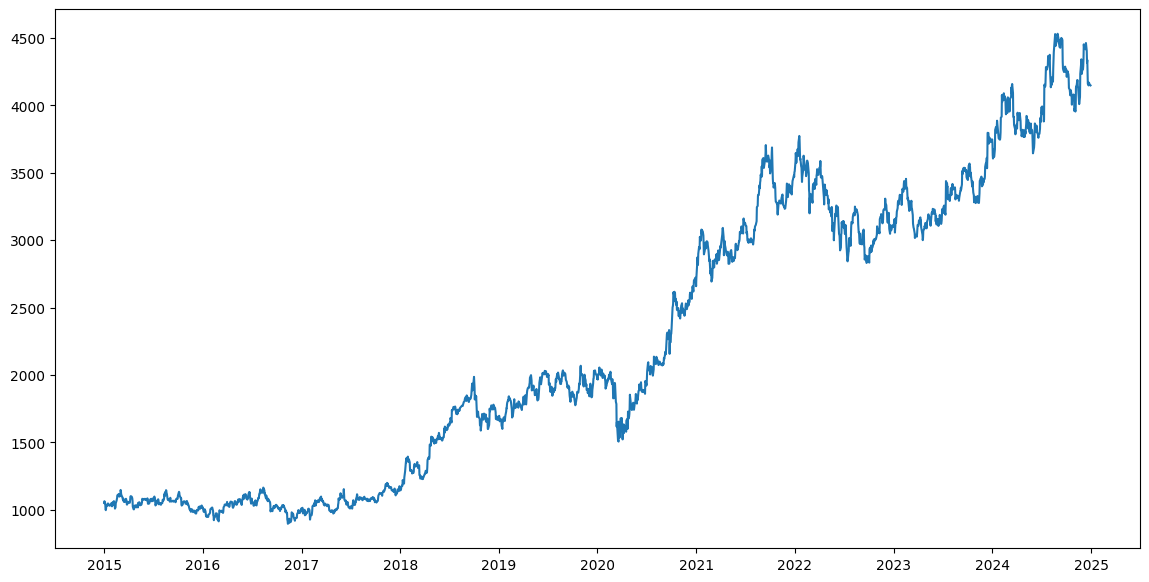

In [4]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label ='close price') 

In [5]:
# Create new features
data['Open - Close'] = data['Open'] - data['Close']
data['High - Low'] = data['High'] - data['Low']
#drop the rows with Nan (if any)
data = data.dropna()


In [6]:
x = data[['Open - Close', 'High - Low']]
x.head(5)

Price,Open - Close,High - Low
Ticker,,
Date,,
2015-01-01,8.842522,10.718233
2015-01-02,-11.728201,16.633814
2015-01-05,16.798774,31.021048
2015-01-06,34.009788,36.730611
2015-01-07,21.560157,29.557567


In [7]:
y = np.where(data['Close'].shift(-1)> data['Close'], 1, -1)
y

array([[ 1],
       [-1],
       [-1],
       ...,
       [-1],
       [-1],
       [-1]])

In [8]:
from sklearn.model_selection import  train_test_split
x_train, x_test, y_train, y_test = train_test_split (x,y, test_size=0.25, random_state=42)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  accuracy_score

In [10]:
# Define possible values of k (n_neighbors)
params = {'n_neighbors': [2,3,4,5,6,7,8,9,10,11,12,13,14,15]}

# Initialize KNN classifier (default parameters)
knn = neighbors.KNeighborsClassifier()

# GridSearchCV = Exhaustively search for best k
model = GridSearchCV(knn, params, cv=5)

#fit the model 
model.fit(x_train,y_train)


c:\Users\ABDULLAH AL MAHMUD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ABDULLAH AL MAHMUD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ABDULLAH AL MAHMUD\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ABDULLAH AL MAHMUD\AppData\Local\Programs\Python\Python312\Lib\site

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                         14, 15]})

In [11]:
#accuracy of the model 
accuracy_train = accuracy_score(y_train, model.predict(x_train))
accuracy_test = accuracy_score(y_test,model.predict(x_test))

print("Train_data accuracy: %.2f" %accuracy_train)
print("test_accuracy: %.2f" %accuracy_test) 

Train_data accuracy: 0.65
test_accuracy: 0.47


In [12]:
print(f"Train Accuracy: {accuracy_train*100:.2f}%")
print(f"Test Accuracy: {accuracy_test*100:.2f}%")


Train Accuracy: 65.22%
Test Accuracy: 47.49%


In [13]:
prediction_classification = model.predict(x_test)

# Ensure both are 1D Series/List
actual_classification = pd.DataFrame({
    "Actual class": list(y_test),
    "Predicted class": list(prediction_classification)
})

actual_classification.head(10)


,Actual class,Predicted class
0,[-1],-1
1,[-1],-1
2,[-1],1
3,[-1],1
4,[1],-1
5,[-1],1
6,[1],-1
7,[-1],1
8,[1],1
9,[-1],1


In [14]:
y = data['Close']
y.head(10)

Ticker,TCS.NS
Date,
2015-01-01,1049.376831
2015-01-02,1063.351807
2015-01-05,1047.192261
2015-01-06,1008.586060
2015-01-07,996.671936
2015-01-08,1007.431763
2015-01-09,1035.669800
2015-01-12,1034.597900
2015-01-13,1029.733398


In [15]:
from sklearn.neighbors import  KNeighborsClassifier
from sklearn import  neighbors

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x,y, test_size=0.25,random_state=44)

#using gridsearchcv  to find the best parameter 
params = {"n_neighbors": [2,3,4,5,6,7,8,9,10,11,12,13,14,15]}
knn_reg = neighbors.KNeighborsRegressor()
model_reg = GridSearchCV(knn_reg,params, cv=5)

#fit the model and make prediction 
model_reg.fit(x_train_reg,y_train_reg)
prediction = model_reg.predict(x_test_reg)

In [16]:
print(prediction)

[[2604.3501709 ]
 [2996.42837728]
 [3230.37379557]
 [1088.4428304 ]
 [2733.01527507]
 [1301.9957194 ]
 [2895.34823812]
 [2709.75218099]
 [1234.82162679]
 [2643.07390951]
 [2593.84930827]
 [2565.72772217]
 [1542.83499756]
 [3416.84193522]
 [1055.96420898]
 [1084.4236735 ]
 [1199.80232747]
 [2262.30912272]
 [1090.71140544]
 [2258.52085775]
 [1147.37543945]
 [1056.30601807]
 [1082.05169678]
 [2698.09910482]
 [1121.86170654]
 [2927.45519206]
 [2717.62831217]
 [1743.79851074]
 [2713.11740723]
 [2876.63081868]
 [1574.86989339]
 [3275.13028971]
 [1120.88774414]
 [3203.39724935]
 [2758.51495768]
 [1704.02097575]
 [2863.73991699]
 [1966.33513997]
 [2352.57840169]
 [3584.28586426]
 [1179.13006592]
 [2667.78564453]
 [1596.85153809]
 [2043.68940023]
 [1088.19464518]
 [2661.33016764]
 [1309.67173258]
 [1228.10023193]
 [3141.04190267]
 [2810.28654785]
 [1271.6192098 ]
 [3226.8240804 ]
 [3198.22261556]
 [2980.60489095]
 [3290.94630534]
 [1111.35174967]
 [2647.98554688]
 [3174.58730469]
 [1367.1985514

In [17]:
#rmse of the model
rms = np.sqrt(np.mean(np.power((np.array(y_test_reg)-np.array(prediction)),2)))
rms

723.1034384361398

In [18]:
print("Length of y_test_reg:", len(y_test_reg))
print("Length of prediction:", len(prediction))


Length of y_test_reg: 617
Length of prediction: 617


In [19]:
print("Shape of y_test_reg:", np.array(y_test_reg).shape)
print("Shape of prediction:", np.array(prediction).shape)


Shape of y_test_reg: (617, 1)
Shape of prediction: (617, 1)


In [20]:
prediction = prediction.flatten()  # Make 1D
prediction = prediction.ravel()


In [21]:
# Flatten both arrays to make them 1D
y_test_reg_flat = np.array(y_test_reg).flatten()
prediction_flat = np.array(prediction).flatten()

# Now create DataFrame
valids = pd.DataFrame({
    "Actual": y_test_reg_flat,
    "Predicted Close": prediction_flat,
})

valids.head()


,Actual,Predicted Close
0,1755.375732,2604.350171
1,3151.956787,2996.428377
2,3394.988525,3230.373796
3,1085.151733,1088.442830
4,3048.330566,2733.015275
